# 15 · Results, hypotheses and figures

Reads every logged metric, builds the tables, decides each pilot hypothesis by its pre-registered rule and draws the figures. No number is typed by hand, so rerun this notebook whenever a run changes.

| | |
|---|---|
| **Kaggle settings** | Accelerator **GPU T4 x2**, Internet **on** |
| **Inputs to attach** | `cffm-net-pilot` and the **saved outputs of notebooks 04, 05, 07, 08 and 09** |
| **Expected runtime** | a few minutes |
| **Produces** | `results/` with tables (Markdown, LaTeX, CSV) and figures (PNG, PDF) |

In [1]:
import glob, shutil, subprocess, sys
from pathlib import Path

ON_KAGGLE = Path("/kaggle/working").exists()
if ON_KAGGLE:
    PROJECT = Path("/kaggle/working/cffm-net-pilot")
    if not PROJECT.exists():
        hits = [Path(p).parent for k in range(1, 6) for p in glob.glob("/kaggle/input" + "/*" * k + "/pyproject.toml")
                if (Path(p).parent / "src" / "cffm").is_dir()]
        hits.sort(key=lambda h: any((h.parent / d).exists() for d in ("runs", "data")))
        zips = [Path(p) for k in range(1, 5) for p in glob.glob("/kaggle/input" + "/*" * k + ".zip")
                if "cffm" in Path(p).name]
        if hits:
            shutil.copytree(hits[0], PROJECT, copy_function=shutil.copyfile)
        elif zips:
            shutil.unpack_archive(str(zips[0]), "/kaggle/working")
        assert PROJECT.exists(), "Add the 'cffm-net-pilot' dataset (the uploaded zip) as an input to this notebook."
        for p in [PROJECT, *PROJECT.rglob("*")]:
            p.chmod(p.stat().st_mode | 0o200)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ultralytics==8.4.171",
                    "faster-coco-eval>=1.6.7", "cloudpickle", "pytest", "lap>=0.5.12", "imageio-ffmpeg"], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--no-deps", "-e", str(PROJECT)], check=True)
else:
    PROJECT = next(p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "src" / "cffm").is_dir())
sys.path.insert(0, str(PROJECT / "src"))

import cffm
from cffm import env as cenv, pipeline
print("cffm", cffm.__version__, "imported from", Path(cffm.__file__).parent)
env = cenv.setup()
plan = pipeline.load_plan(env.project)

cffm 0.1.0 imported from C:\Users\roshh\Desktop\computer vision\cffm-net-pilot\src\cffm
platform=local  device=0  gpus=[NVIDIA GeForce RTX 4050 Laptop GPU (6 GB)]  scan=torch
project=C:\Users\roshh\Desktop\computer vision\cffm-net-pilot
data=C:\Users\roshh\Desktop\computer vision\cffm-net-pilot\data\processed
runs=C:\Users\roshh\Desktop\computer vision\cffm-net-pilot\runs


In [2]:
import json
from cffm import report
ev = pipeline.find_metrics(env, "eval")
pr = pipeline.find_metrics(env, "probe")
lat = {}
for root in [env.runs, *[r for r in pipeline.INPUT_ROOTS if r.exists()]]:
    for f in root.glob("**/latency/latency.json"):
        lat.update({k: v for k, v in json.loads(f.read_text()).items() if k not in lat})
print(len(ev), "evaluated runs,", len(pr), "probe results,", len(lat), "latency entries")
out = env.project / "results"; out.mkdir(exist_ok=True)

10 evaluated runs, 27 probe results, 8 latency entries


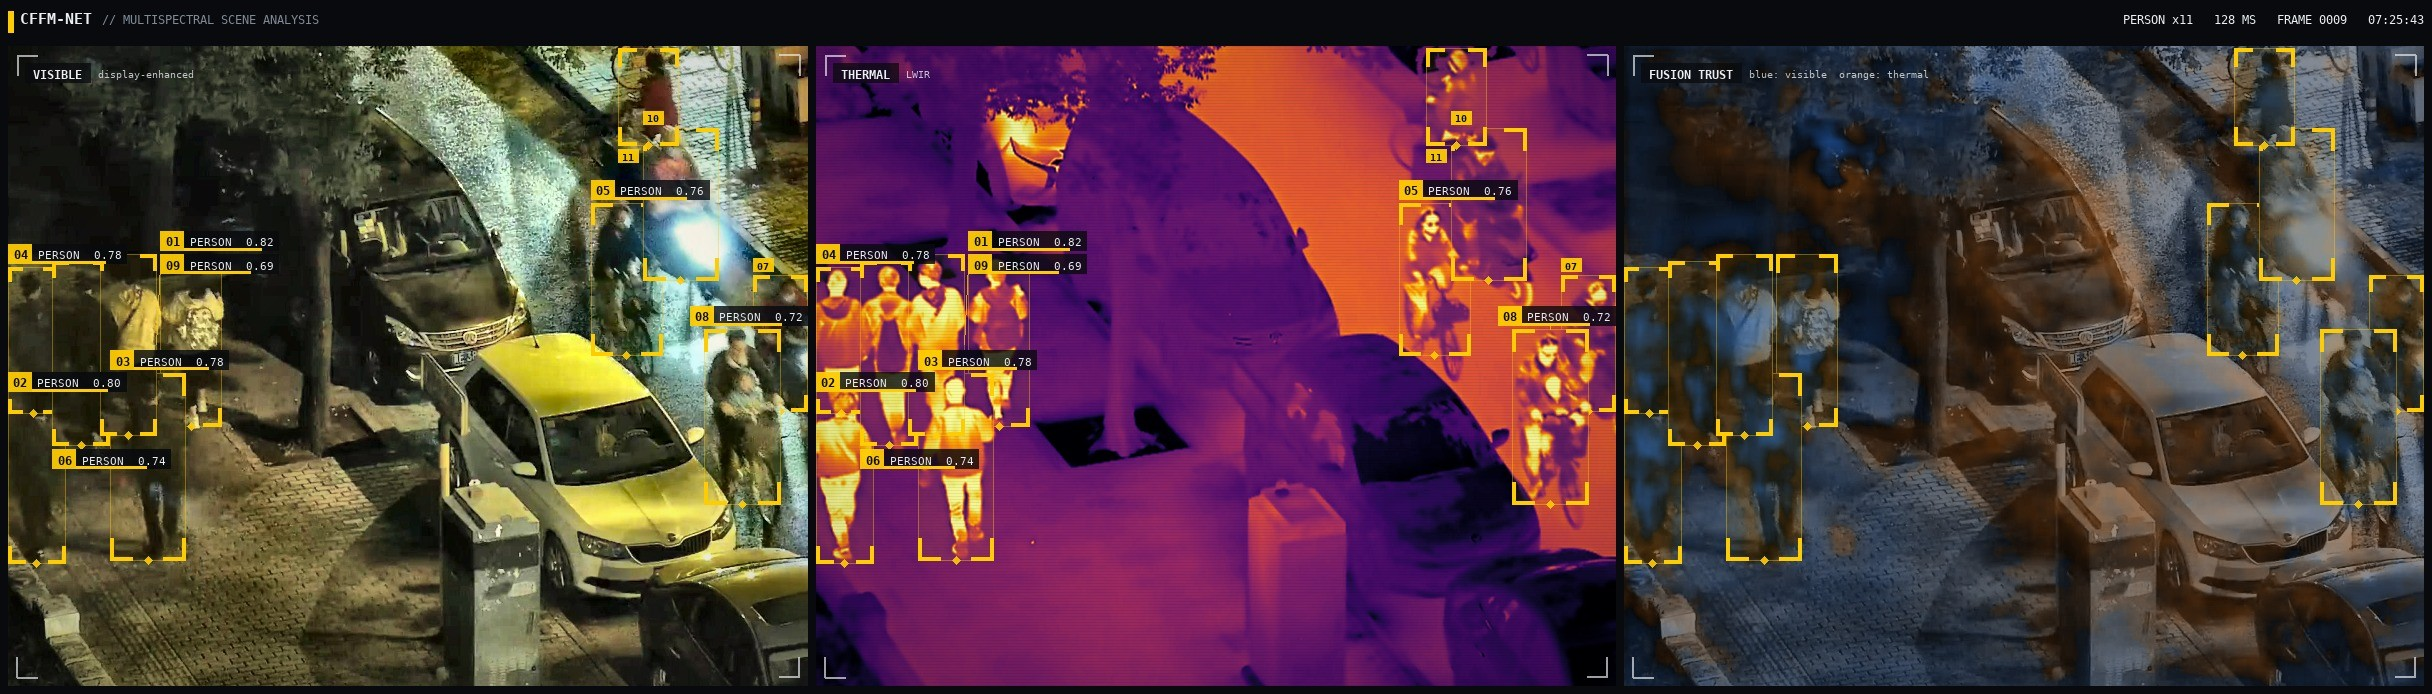

In [3]:
import cv2
from cffm import showcase as sc
hero = out / "showcase" / "hero_llvip.jpg"
if hero.exists():
    sc.show(cv2.cvtColor(cv2.imread(str(hero)), cv2.COLOR_BGR2RGB))

## 1. Main results

AP is COCO AP50-95 on the full validation set, AP_vt / AP_t / AP_s the AI-TOD bands (<8, 8-16, 16-32 px). Cost is one T4, FP16, batch 1.

In [4]:
main = report.main_table(ev, lat)
main.round(4)

,AP,AP50,AP_small,AP_vt,AP_t,AP_s,params_M,GFLOPs,median_ms
run,,,,,,,,,
llvip_yolo26n_visible,0.5195,0.8999,0.0933,NaN,NaN,0.0933,2.5042,5.8922,17.2100
llvip_yolo26n_thermal,0.6409,0.9615,0.0642,NaN,NaN,0.0643,2.5042,5.8922,16.9800
llvip_concat,0.6495,0.9676,0.1274,NaN,NaN,0.1276,4.0673,9.7081,23.4440
llvip_cffm,0.6289,0.9576,0.0885,NaN,NaN,0.0885,6.0313,18.3875,41.9056
llvip_cffm_nogate,0.6257,0.9596,0.0645,NaN,NaN,0.0645,6.0088,18.1386,41.0870
llvip_cffm_gconv,0.6279,0.9597,0.0612,NaN,NaN,0.0615,6.1537,18.2952,34.6948
m3fd_concat,0.5047,0.7820,0.3149,0.0641,0.2215,0.4455,4.0692,9.7189,24.0353
m3fd_cffm,0.4790,0.7726,0.2974,0.0595,0.1899,0.4275,6.0326,18.4092,42.4553
llvip_cffm_nop2b,0.6350,0.9604,0.0750,NaN,NaN,0.0750,NaN,NaN,NaN


## 2. The hypotheses, decided by the rules written down before training

Thresholds are in AP points (0.015 = 1.5 points). A difference inside the threshold is **inconclusive**, since
one seed per configuration varies by about 1 to 1.5 points.

In [5]:
hyp = report.decide(ev, pr, lat, plan["probe"]["kinds"])
hyp

,hypothesis,evidence,verdict
id,,,
PH1,fusion beats the best single sensor at night,-0.0120 AP vs thermal-only,inconclusive
PH2,gating the step adds value,clean +0.0032 AP; degrades less by +0.0130 AP,inconclusive
PH3,the pathway helps 8-32 px objects (M3FD),-0.0248 AP in the 8-32 px bands,against
PH4,the selective scan is needed,+0.0010 AP vs gated-conv control,inconclusive
PH5,latency at most 2x the two-stream baseline,ratio 1.79,supported


## 3. Figures

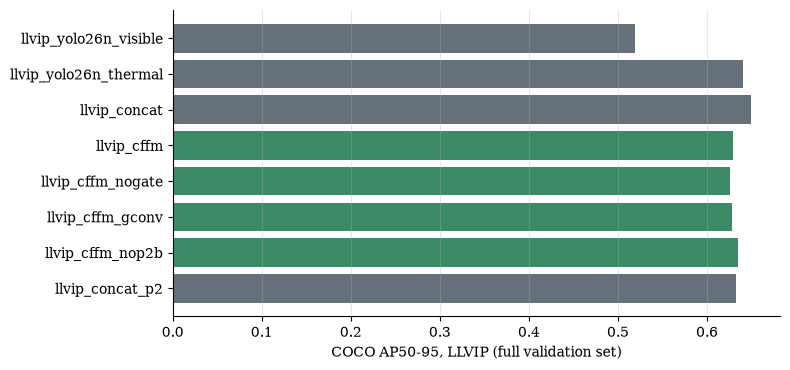

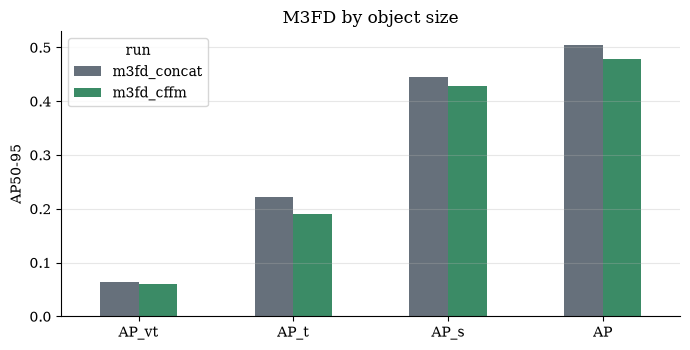

In [6]:
import matplotlib.pyplot as plt
plt.rcParams.update({"font.family": "serif", "axes.spines.top": False, "axes.spines.right": False})

llvip = main[main.index.str.startswith("llvip")]
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.barh(llvip.index, llvip["AP"], color=["#3B8B66" if "cffm" in i else "#66707B" for i in llvip.index])
ax.set_xlabel("COCO AP50-95, LLVIP (full validation set)"); ax.invert_yaxis(); ax.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.savefig(out / "fig_llvip_ap.png", dpi=200); plt.savefig(out / "fig_llvip_ap.pdf"); plt.show()

m3 = main.loc[[r for r in ("m3fd_concat", "m3fd_cffm") if r in main.index], ["AP_vt", "AP_t", "AP_s", "AP"]]
if len(m3):
    ax = m3.T.plot(kind="bar", figsize=(7, 3.6), color=["#66707B", "#3B8B66"], rot=0)
    ax.set_ylabel("AP50-95"); ax.set_title("M3FD by object size"); ax.grid(axis="y", alpha=0.3)
    plt.tight_layout(); plt.savefig(out / "fig_m3fd_sizes.png", dpi=200); plt.savefig(out / "fig_m3fd_sizes.pdf"); plt.show()

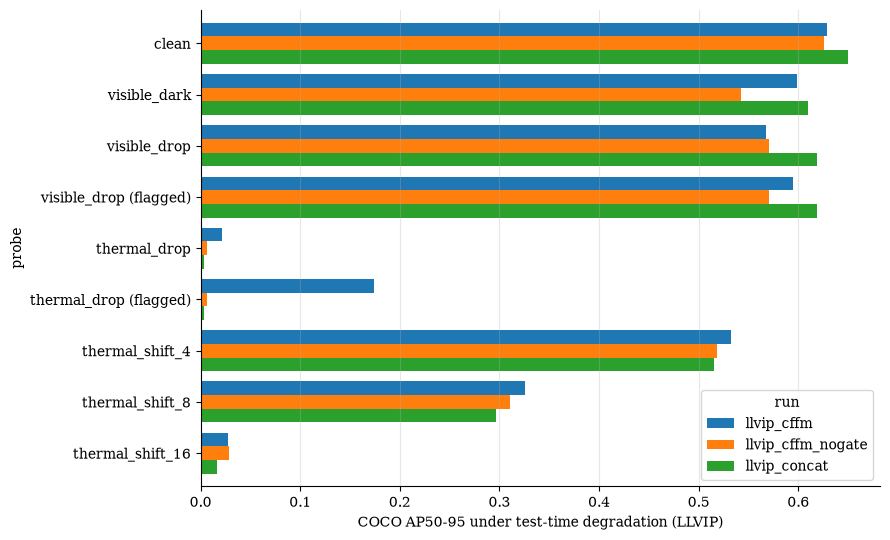

run,llvip_cffm,llvip_cffm_nogate,llvip_concat
probe,,,
clean,0.6289,0.6258,0.6495
visible_dark,0.5985,0.5424,0.6099
visible_drop,0.5674,0.5704,0.6184
visible_drop (flagged),0.5950,0.5704,0.6184
thermal_drop,0.0217,0.0066,0.0029
thermal_drop (flagged),0.1739,0.0066,0.0029
thermal_shift_4,0.5326,0.5180,0.5157
thermal_shift_8,0.3259,0.3110,0.2969
thermal_shift_16,0.0276,0.0286,0.0169


In [7]:
probe = report.probe_table(pr, plan["probe"]["runs"], plan["probe"]["kinds"], plan["probe"]["flagged"])
if len(probe):
    ax = probe.plot(kind="barh", figsize=(9, 5.5), width=0.8)
    ax.set_xlabel("COCO AP50-95 under test-time degradation (LLVIP)"); ax.invert_yaxis(); ax.grid(axis="x", alpha=0.3)
    plt.tight_layout(); plt.savefig(out / "fig_probe.png", dpi=200); plt.savefig(out / "fig_probe.pdf"); plt.show()
probe.round(4)

## 4. Tables for the write-up

Markdown for notes, CSV for spreadsheets and rule-free LaTeX for the paper.

In [8]:
main.round(4).to_csv(out / "main_results.csv")
hyp.to_csv(out / "hypotheses.csv")
if len(probe): probe.round(4).to_csv(out / "probe.csv")
(out / "tables.md").write_text("## Main results\n\n" + report.to_markdown(main) +
                               "\n## Hypotheses\n\n" + report.to_markdown(hyp) +
                               ("\n## Degradation probe\n\n" + report.to_markdown(probe) if len(probe) else ""))
(out / "tables.tex").write_text(report.to_latex(main, "Pilot results, one seed per configuration.", "tab:pilot")
                                + "\n" + report.to_latex(hyp, "Pilot hypotheses and verdicts.", "tab:pilot-hyp"))
print(sorted(p.name for p in out.iterdir()))

['fig_llvip_ap.pdf', 'fig_llvip_ap.png', 'fig_m3fd_sizes.pdf', 'fig_m3fd_sizes.png', 'fig_probe.pdf', 'fig_probe.png', 'hypotheses.csv', 'main_results.csv', 'pilot_v1', 'probe.csv', 'showcase', 'tables.md', 'tables.tex']


### Keep the results

On Kaggle, click **Save Version → Save & Run All (Commit)** so `runs/` becomes an output that notebooks **09**
and **15** can attach (*Add Input → Your Work → this notebook*). Without a saved version the checkpoints vanish.